In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import os
import joblib


In [2]:
df=pd.read_csv(r"D:\university\ai_training\spyder\Cars_Datasets_2025.csv",encoding='latin1')
print(f"shape{df.shape}")
df.head()
df.describe()
print('Missing values:')
print(df.isnull().sum())


shape(1218, 11)
Missing values:
Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          3
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    6
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       1
dtype: int64


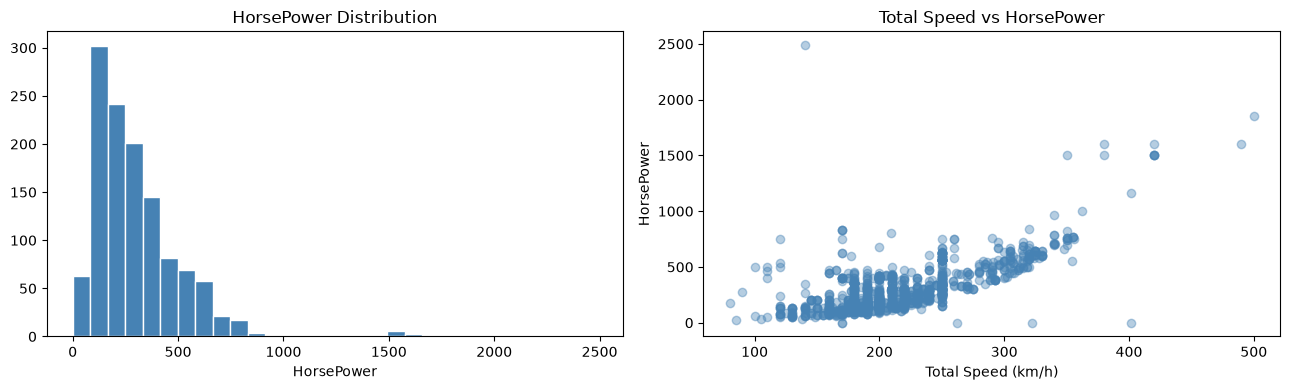

In [3]:
%matplotlib inline
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
axes[0].hist(df['HorsePower'].str.extract(r'(\d+)').astype(float).dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('HorsePower Distribution')
axes[0].set_xlabel('HorsePower')
 
axes[1].scatter(df['Total Speed'].str.extract(r'(\d+)').astype(float),
                 df['HorsePower'].str.extract(r'(\d+)').astype(float),
                 alpha=0.4, color='steelblue')
axes[1].set_title('Total Speed vs HorsePower')
axes[1].set_xlabel('Total Speed (km/h)')
axes[1].set_ylabel('HorsePower')
 
plt.tight_layout()
plt.show()


In [4]:
def parse_num(s):
    if pd.isna(s):
        return np.nan
    s = str(s).replace(',', '')
 
    nums = []
    current = ''
    for ch in s:
        if ch.isdigit() or ch == '.':
            current += ch
        else:
            if current and current != '.':
                nums.append(float(current))
            current = ''
    if current and current != '.':
        nums.append(float(current))
 
    return np.mean(nums) if nums else np.nan


In [5]:
num_cols_raw = ['CC/Battery Capacity', 'HorsePower', 'Total Speed',
                'Performance(0 - 100 )KM/H', 'Cars Prices', 'Seats', 'Torque']
 
for col in num_cols_raw:
    df[col.split('(')[0].strip() + '_num'] = df[col].apply(parse_num)
 


In [6]:
def simplify_fuel(f):
    f = str(f).lower()
    if 'hydrogen' in f:
        return 'Hydrogen'
    if 'hybrid' in f:
        return 'Hybrid'
    if ('electric' in f or f.strip() == 'ev') and 'petrol' not in f and 'diesel' not in f:
        return 'Electric'
    if 'diesel' in f and 'petrol' not in f:
        return 'Diesel'
    if 'petrol' in f or 'gas' in f:
        return 'Petrol'
    return 'Other'
 
df['FuelType'] = df['Fuel Types'].apply(simplify_fuel)
df = df[df['FuelType'].isin(['Petrol', 'Diesel', 'Electric', 'Hybrid'])].copy()
 
print('Encoding done. Sample:')
df.head(3)


Encoding done. Sample:


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque,CC/Battery Capacity_num,HorsePower_num,Total Speed_num,Performance_num,Cars Prices_num,Seats_num,Torque_num,FuelType
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm,6749.0,563.0,250.0,5.3,460000.0,5.0,900.0,Petrol
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm,1200.0,77.5,165.0,10.5,13500.0,5.0,120.0,Petrol
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm,3982.0,630.0,250.0,3.2,161000.0,4.0,900.0,Petrol


In [7]:
feature_cols = ['CC/Battery Capacity_num', 'HorsePower_num', 'Total Speed_num',
                'Performance_num', 'Cars Prices_num', 'Seats_num', 'Torque_num']
 
df = df.dropna(subset=feature_cols)
 
x = df[feature_cols]
y = df['FuelType']
X_train,x_test,Y_train,y_test=train_test_split(x,y,train_size=0.8,test_size=0.2,random_state=42,stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled  = scaler.transform(x_test)
print(f'Train size : {X_train.shape[0]} rows')
print(f'Test  size : {x_test.shape[0]} rows')


Train size : 963 rows
Test  size : 241 rows


In [8]:
candidate_models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=10,
                                            class_weight='balanced', random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                            class_weight='balanced', random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
}

results = {}


In [9]:
for name, clf in candidate_models.items():
    clf.fit(X_train_scaled, Y_train)
    preds = clf.predict(X_test_scaled)
    acc_score = accuracy_score(y_test, preds)
    results[name] = acc_score
    print(f'{name:20s} accuracy: {acc_score:.4f}')



RandomForest         accuracy: 0.7676
DecisionTree         accuracy: 0.7842
GradientBoosting     accuracy: 0.9129
LogisticRegression   accuracy: 0.6639
SVM                  accuracy: 0.6639
KNN                  accuracy: 0.8340


In [10]:
best_name = max(results, key=results.get)
model = candidate_models[best_name]
print(f'\nBest model: {best_name}  (accuracy: {results[best_name]:.4f})')



Best model: GradientBoosting  (accuracy: 0.9129)


In [11]:
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f'Accuracy Score : {acc:.4f}   (1.0 = perfect)')
print()
print(classification_report(y_test, y_pred))


Accuracy Score : 0.9129   (1.0 = perfect)

              precision    recall  f1-score   support

      Diesel       0.94      0.80      0.86        20
    Electric       1.00      1.00      1.00        19
      Hybrid       0.71      0.45      0.56        22
      Petrol       0.92      0.97      0.94       180

    accuracy                           0.91       241
   macro avg       0.89      0.81      0.84       241
weighted avg       0.91      0.91      0.91       241



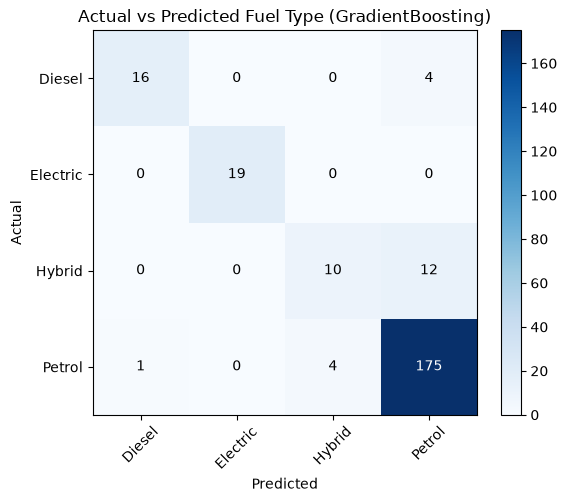

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title(f'Actual vs Predicted Fuel Type ({best_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(range(len(model.classes_)), model.classes_, rotation=45)
plt.yticks(range(len(model.classes_)), model.classes_)
for i in range(len(model.classes_)):
    for j in range(len(model.classes_)):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar()
plt.tight_layout()
plt.show()


In [13]:
os.makedirs('models', exist_ok=True)
 
joblib.dump(model,  'models/model.pkl')
 
joblib.dump(scaler, 'models/scaler.pkl')
 
joblib.dump(list(x.columns), 'models/columns.pkl')

joblib.dump(list(model.classes_), 'models/classes.pkl')
 
print('Saved:')
print(f'   (best model was: {best_name})')
for f in os.listdir('models'):
    if f.endswith('.pkl'):
        size = os.path.getsize(f'models/{f}')
        print(f'   models/{f}  ({size:,} bytes)')
m = joblib.load('models/model.pkl')
s = joblib.load('models/scaler.pkl')
c = joblib.load('models/columns.pkl')
classes = joblib.load('models/classes.pkl')
 
sample = pd.DataFrame([{
    'CC/Battery Capacity_num': 3990, 'HorsePower_num': 963, 'Total Speed_num': 340,
    'Performance_num': 2.5, 'Cars Prices_num': 1100000, 'Seats_num': 2, 'Torque_num': 800
}])[c]
 
fuel_type = m.predict(s.transform(sample))[0]
print(f'Sample prediction: {fuel_type}  (sanity check passed)')

Saved:
   (best model was: GradientBoosting)
   models/classes.pkl  (54 bytes)
   models/columns.pkl  (138 bytes)
   models/model.pkl  (520,521 bytes)
   models/scaler.pkl  (1,103 bytes)
Sample prediction: Petrol  (sanity check passed)
